# Phase 1 — Data and geographic assessment

Mérida Urban Intelligence · Geospatial Data Warehouse

This notebook profiles the original sources, evaluates the candidate geographic units, inspects
the official polygons and tests the point-to-polygon integration. It reads the raw files only to
assess them; nothing here feeds a reported KPI. Run `python -m src.download` first.

In [1]:
import json
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from src import config

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
summary = {}  # figures collected along the notebook, saved at the end

## 1. Source inventory

Provenance recorded by the download step (`docs/source_manifest.json`).

In [2]:
manifest = json.loads(config.SOURCE_MANIFEST.read_text(encoding="utf-8"))
pd.DataFrame(manifest).T[["provider", "edition", "original_grain", "file_name",
                          "size_bytes", "download_date", "sha256"]]

,provider,edition,original_grain,file_name,size_bytes,download_date,sha256
census,INEGI,2020,"one row per urban block, with total rows per A...",ageb_mza_urbana_31_cpv2020_csv.zip,6044441,2026-09-30,5cc69c7a9f0f248e1e19f960b4498a5459d4bedbc1bdc5...
geography,INEGI,2020,"one polygon per geostatistical area (state, mu...",31_yucatan.zip,50570164,2026-09-30,c486f642edbae13e51e219374d15f432758d565f86bc83...
denue,INEGI,latest published (see download date),one row per establishment,denue_31_csv.zip,10832360,2026-09-30,a47d4054f2cdeb5ebfce0da8ce1934cb830417174c5041...


## 2. Demographic source — Census 2020, urban AGEB and block results

One file for the state. Each row is a block (*manzana*); total rows for the state, municipality,
locality and AGEB are interleaved and identified by zero codes in the lower levels.

In [3]:
census_file = next((config.DATA_RAW / "census" / "extracted").rglob("conjunto_de_datos_ageb_urbana_31_cpv2020.csv"))
census = pd.read_csv(census_file, dtype=str, encoding="utf-8")
print("rows, columns:", census.shape)

mun = census[census["MUN"] == config.MUNICIPALITY_CODE].copy()


def level(row):
    if row["LOC"] == "0000":
        return "municipality total"
    if row["AGEB"] == "0000":
        return "locality total"
    if row["MZA"] == "000":
        return "AGEB total"
    return "block"


mun["level"] = mun.apply(level, axis=1)
levels = mun["level"].value_counts()
summary["census_rows_state"] = int(len(census))
summary["census_rows_municipality"] = int(len(mun))
summary["census_levels"] = {k: int(v) for k, v in levels.items()}
levels.to_frame("rows in Mérida (050)")

rows, columns: (40140, 230)


,rows in Mérida (050)
level,
block,16540
AGEB total,526
locality total,6
municipality total,1


### Variables required by the KPIs

| KPI | Census variables |
|---|---|
| Total population, population density | `POBTOT` |
| Economically active population rate | `PEA`, `P_12YMAS` |
| Population by age group | `POB0_14`, `POB15_64`, `POB65_MAS` |
| Employment context | `POCUPADA` |
| Housing | `VIVTOT`, `TVIVHAB`, `PROM_OCUP` |

In [4]:
KPI_VARS = ["POBTOT", "P_12YMAS", "PEA", "POCUPADA", "POB0_14", "POB15_64", "POB65_MAS",
            "VIVTOT", "TVIVHAB", "PROM_OCUP"]
missing_cols = [c for c in KPI_VARS if c not in census.columns]
print("KPI variables missing from the file:", missing_cols or "none")

# Non-numeric markers used by the source
markers = {}
for col in KPI_VARS:
    values = mun[col]
    bad = values[pd.to_numeric(values, errors="coerce").isna()]
    for marker, n in bad.value_counts().items():
        markers[marker] = markers.get(marker, 0) + int(n)
print("non-numeric markers in the KPI variables:", markers)

KPI variables missing from the file: none
non-numeric markers in the KPI variables: {'*': 9817, 'N/D': 49}


In [5]:
def suppression(frame):
    out = {}
    for col in KPI_VARS:
        numeric = pd.to_numeric(frame[col], errors="coerce")
        out[col] = numeric.isna().mean() * 100
    return pd.Series(out)


suppressed = pd.DataFrame({
    "block (% not available)": suppression(mun[mun["level"] == "block"]),
    "AGEB (% not available)": suppression(mun[mun["level"] == "AGEB total"]),
})
summary["suppression_pct"] = suppressed.round(2).to_dict()
suppressed

,block (% not available),AGEB (% not available)
POBTOT,0.00,0.00
P_12YMAS,4.56,0.76
PEA,4.81,0.76
POCUPADA,4.85,0.76
POB0_14,10.85,1.33
POB15_64,4.65,0.76
POB65_MAS,23.46,2.66
VIVTOT,0.00,0.00
TVIVHAB,1.67,0.57
PROM_OCUP,4.54,0.76


In [6]:
ageb_rows = mun[mun["level"] == "AGEB total"].copy()
block_rows = mun[mun["level"] == "block"].copy()
for frame in (ageb_rows, block_rows):
    frame["POBTOT_n"] = pd.to_numeric(frame["POBTOT"], errors="coerce")

municipal_total = int(mun.loc[mun["level"] == "municipality total", "POBTOT"].iloc[0])
summary["population_municipality"] = municipal_total
summary["population_sum_ageb"] = int(ageb_rows["POBTOT_n"].sum())
summary["ageb_census_rows"] = int(len(ageb_rows))
summary["ageb_by_locality"] = {k: int(v) for k, v in ageb_rows["LOC"].value_counts().items()}
print("municipality total population :", f"{municipal_total:,}")
print("sum of urban AGEB totals      :", f"{summary['population_sum_ageb']:,}")
print("urban AGEBs in the census     :", len(ageb_rows))
ageb_rows["POBTOT_n"].describe().to_frame("population per AGEB")

municipality total population : 995,129
sum of urban AGEB totals      : 957,399
urban AGEBs in the census     : 526


,population per AGEB
count,526.00
mean,"1,820.15"
std,"1,188.47"
min,0.00
25%,972.25
50%,"1,755.00"
75%,"2,591.00"
max,"7,244.00"


## 3. Economic source — DENUE

One row per establishment, with SCIAN activity, employment stratum, the AGEB and block keys
declared by INEGI, and latitude/longitude.

In [7]:
denue_file = config.DATA_RAW / "denue" / "extracted" / "conjunto_de_datos" / "denue_inegi_31_.csv"
denue_all = pd.read_csv(denue_file, dtype=str, encoding="latin-1")
denue = denue_all[denue_all["cve_mun"] == config.MUNICIPALITY_CODE].copy()
denue["latitud"] = pd.to_numeric(denue["latitud"], errors="coerce")
denue["longitud"] = pd.to_numeric(denue["longitud"], errors="coerce")

summary["denue_rows_state"] = int(len(denue_all))
summary["denue_rows_municipality"] = int(len(denue))
summary["denue_duplicate_ids"] = int(denue["id"].duplicated().sum())
summary["denue_missing_coordinates"] = int(denue[["latitud", "longitud"]].isna().any(axis=1).sum())
summary["denue_missing_ageb"] = int(denue["ageb"].isna().sum())
summary["denue_fecha_alta_max"] = str(denue["fecha_alta"].max())
print("state rows:", len(denue_all), "| Mérida rows:", len(denue))
print("duplicate ids:", summary["denue_duplicate_ids"])
print("missing coordinates:", summary["denue_missing_coordinates"])
print("missing AGEB key:", summary["denue_missing_ageb"])
print("latest registration month (fecha_alta):", summary["denue_fecha_alta_max"])
denue[["latitud", "longitud"]].describe()

state rows: 146384 | Mérida rows: 56909
duplicate ids: 0
missing coordinates: 0
missing AGEB key: 0
latest registration month (fecha_alta): 2026-04


,latitud,longitud
count,"56,909.00","56,909.00"
mean,20.98,-89.63
std,0.04,0.04
min,20.77,-89.73
25%,20.96,-89.65
50%,20.98,-89.62
75%,21.00,-89.60
max,21.16,-89.49


In [8]:
denue["sector_code"] = denue["codigo_act"].str[:2]
sectors = denue["sector_code"].value_counts().sort_index().to_frame("establishments")
sectors["share %"] = sectors["establishments"] / len(denue) * 100
summary["denue_sectors"] = {k: int(v) for k, v in sectors["establishments"].items()}
sectors

,establishments,share %
sector_code,,
11,14,0.02
21,3,0.01
22,60,0.11
23,777,1.37
31,2019,3.55
32,844,1.48
33,1236,2.17
43,2071,3.64
46,19441,34.16


In [9]:
size = denue["per_ocu"].value_counts().to_frame("establishments")
summary["denue_size_classes"] = {k: int(v) for k, v in size["establishments"].items()}
size

,establishments
per_ocu,
0 a 5 personas,45587
6 a 10 personas,5364
11 a 30 personas,4169
31 a 50 personas,773
51 a 100 personas,519
101 a 250 personas,332
251 y más personas,165


## 4. Geographic source — Marco Geoestadístico 2020

Layers used: `31a` urban AGEBs, `31m` blocks, `31l` urban localities, `31mun` municipalities.

In [10]:
geo_dir = config.DATA_RAW / "geography" / "extracted" / "conjunto_de_datos"
layers = {}
rows = []
for code_, label in [("31a", "urban AGEB"), ("31m", "block"), ("31l", "locality"),
                     ("31mun", "municipality")]:
    layer = gpd.read_file(geo_dir / f"{code_}.shp")
    layers[code_] = layer
    in_mun = layer[layer["CVE_MUN"] == config.MUNICIPALITY_CODE]
    rows.append({
        "layer": code_, "unit": label, "CRS": layer.crs.name, "EPSG": layer.crs.to_epsg(),
        "state polygons": len(layer), "Mérida polygons": len(in_mun),
        "invalid geometries (Mérida)": int((~in_mun.is_valid).sum()),
        "duplicate CVEGEO (Mérida)": int(in_mun["CVEGEO"].duplicated().sum()),
        "geometry types": ", ".join(sorted(in_mun.geom_type.unique())),
        "fields": ", ".join(c for c in layer.columns if c != "geometry"),
    })
inspection = pd.DataFrame(rows).set_index("layer")
summary["geography_inspection"] = inspection.drop(columns="fields").to_dict("index")
inspection

,unit,CRS,EPSG,state polygons,Mérida polygons,invalid geometries (Mérida),duplicate CVEGEO (Mérida),geometry types,fields
layer,,,,,,,,,
31a,urban AGEB,MEXICO_ITRF_2008_LCC,None,1532,526,0,0,Polygon,"CVEGEO, CVE_ENT, CVE_MUN, CVE_LOC, CVE_AGEB"
31m,block,MEXICO_ITRF_2008_LCC,None,48021,17595,0,0,Polygon,"CVEGEO, CVE_ENT, CVE_MUN, CVE_LOC, CVE_AGEB, C..."
31l,locality,MEXICO_ITRF_2008_LCC,None,655,53,0,0,"MultiPolygon, Polygon","CVEGEO, CVE_ENT, CVE_MUN, CVE_LOC, NOMGEO, AMBITO"
31mun,municipality,MEXICO_ITRF_2008_LCC,None,106,1,0,0,Polygon,"CVEGEO, CVE_ENT, CVE_MUN, NOMGEO"


In [11]:
ageb = layers["31a"][layers["31a"]["CVE_MUN"] == config.MUNICIPALITY_CODE].copy()
print("source CRS:", ageb.crs.name, "| units:", ageb.crs.axis_info[0].unit_name)
# The .prj carries no EPSG code. Its projection parameters are compared with EPSG:6372
# (Mexico ITRF2008 / LCC); being identical, the layers are declared as EPSG:6372 from here on.
import warnings
import pyproj
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    same = ageb.crs.to_proj4() == pyproj.CRS(config.CRS_METRIC).to_proj4()
print("projection parameters identical to EPSG:6372:", same)
summary["source_crs_matches_epsg_6372"] = bool(same)
ageb = ageb.set_crs(config.CRS_METRIC, allow_override=True)
ageb["area_km2"] = ageb.area / 1e6
summary["ageb_polygons"] = int(len(ageb))
summary["ageb_area_km2_total"] = float(ageb["area_km2"].sum())
ageb["area_km2"].describe().to_frame("AGEB area (km²)")

source CRS: MEXICO_ITRF_2008_LCC | units: metre
projection parameters identical to EPSG:6372: True


,AGEB area (km²)
count,526.00
mean,0.49
std,0.45
min,0.01
25%,0.27
50%,0.41
75%,0.58
max,6.55


### Do census keys and polygon keys match?

The census key is built as `ENTIDAD + MUN + LOC + AGEB`, the same structure as `CVEGEO` in the
AGEB layer.

In [12]:
ageb_rows["cvegeo"] = ageb_rows["ENTIDAD"] + ageb_rows["MUN"] + ageb_rows["LOC"] + ageb_rows["AGEB"]
census_keys, polygon_keys = set(ageb_rows["cvegeo"]), set(ageb["CVEGEO"])
summary["keys_census_only"] = sorted(census_keys - polygon_keys)
summary["keys_polygon_only"] = sorted(polygon_keys - census_keys)
print("AGEBs in the census      :", len(census_keys))
print("AGEB polygons            :", len(polygon_keys))
print("in both                  :", len(census_keys & polygon_keys))
print("census without polygon   :", len(summary["keys_census_only"]))
print("polygon without census   :", len(summary["keys_polygon_only"]))

AGEBs in the census      : 526
AGEB polygons            : 526
in both                  : 526
census without polygon   : 0
polygon without census   : 0


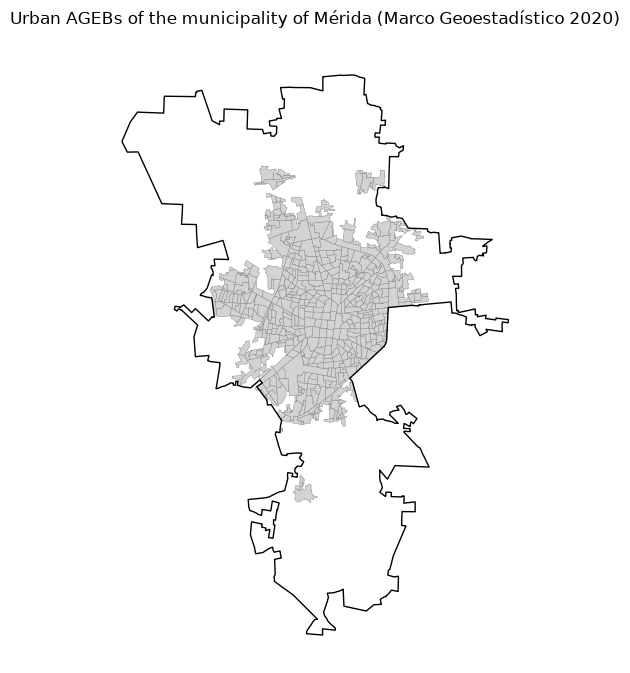

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))
layers["31mun"][layers["31mun"]["CVE_MUN"] == config.MUNICIPALITY_CODE].boundary.plot(ax=ax, color="black", linewidth=1)
ageb.plot(ax=ax, facecolor="lightgrey", edgecolor="grey", linewidth=0.3)
ax.set_title("Urban AGEBs of the municipality of Mérida (Marco Geoestadístico 2020)")
ax.set_axis_off()
plt.show()

## 5. Candidate geographic units

Measured on the downloaded data. *Colonia* is listed for completeness: INEGI publishes neither
colonia polygons nor census results by colonia, so it cannot be measured here.

In [14]:
blocks = layers["31m"][layers["31m"]["CVE_MUN"] == config.MUNICIPALITY_CODE]
localities = layers["31l"][layers["31l"]["CVE_MUN"] == config.MUNICIPALITY_CODE]

denue_valid = denue.dropna(subset=["latitud", "longitud"]).copy()
denue_valid["block_key"] = (denue_valid["cve_ent"] + denue_valid["cve_mun"] + denue_valid["cve_loc"]
                            + denue_valid["ageb"] + denue_valid["manzana"])
denue_valid["ageb_key"] = denue_valid["cve_ent"] + denue_valid["cve_mun"] + denue_valid["cve_loc"] + denue_valid["ageb"]

pea_block = pd.to_numeric(block_rows["PEA"], errors="coerce")
pea_ageb = pd.to_numeric(ageb_rows["PEA"], errors="coerce")

candidates = pd.DataFrame({
    "official polygons": ["yes (31m)", "yes (31a)", "not published by INEGI", "yes (31l)"],
    "census results": ["yes", "yes", "no", "yes"],
    "units in Mérida": [len(blocks), len(ageb), None, len(localities)],
    "median population": [block_rows["POBTOT_n"].median(), ageb_rows["POBTOT_n"].median(), None, None],
    "PEA not available (%)": [pea_block.isna().mean() * 100, pea_ageb.isna().mean() * 100, None, None],
    "units without any business (%)": [
        (1 - blocks["CVEGEO"].isin(denue_valid["block_key"]).mean()) * 100,
        (1 - ageb["CVEGEO"].isin(denue_valid["ageb_key"]).mean()) * 100, None, None],
}, index=["block (manzana)", "urban AGEB", "colonia", "locality"])
summary["candidate_units"] = candidates.round(2).astype(object).where(candidates.notna(), None).to_dict("index")
candidates

,official polygons,census results,units in Mérida,median population,PEA not available (%),units without any business (%)
block (manzana),yes (31m),yes,"17,595.00",52.00,4.81,33.04
urban AGEB,yes (31a),yes,526.00,"1,755.00",0.76,3.04
colonia,not published by INEGI,no,NaN,NaN,NaN,NaN
locality,yes (31l),yes,53.00,NaN,NaN,NaN


**Reading.** Blocks are too small: the median block has about fifty residents, confidentiality
withholds several variables far more often than at AGEB level (see the suppression table in
section 2), and about a third of the blocks contain no establishment, so rates would rest on
tiny denominators or be undefined. Localities are too few, and one of them holds almost all
the population, so they show no variation inside the city. Colonias have no
official polygons and no census results, so using them would require estimating population by
areal interpolation. The urban AGEB has official polygons, complete census results with the same
key, and enough units for spatial statistics. The decision is documented in
`docs/geographic_unit_decision.md`.

## 6. Point-to-polygon integration test

Establishment coordinates (WGS84) are turned into points and joined to the AGEB polygons. DENUE
also declares an AGEB key for each establishment, which gives an independent check of the
spatial result.

In [15]:
points = gpd.GeoDataFrame(
    denue_valid[["id", "ageb_key", "codigo_act"]],
    geometry=gpd.points_from_xy(denue_valid["longitud"], denue_valid["latitud"]),
    crs=config.CRS_STORAGE,
).to_crs(ageb.crs)

joined = gpd.sjoin(points, ageb[["CVEGEO", "geometry"]], how="left", predicate="within")
multi = int(joined["id"].duplicated().sum())
joined = joined.drop_duplicates("id")

matched = joined["CVEGEO"].notna()
agree = (joined["CVEGEO"] == joined["ageb_key"]) & matched
declared_urban = joined["ageb_key"].isin(set(ageb["CVEGEO"]))

result = {
    "establishments with valid coordinates": int(len(joined)),
    "assigned to an urban AGEB polygon": int(matched.sum()),
    "not inside any urban AGEB polygon": int((~matched).sum()),
    "match rate (%)": round(matched.mean() * 100, 2),
    "points inside more than one polygon": multi,
    "spatial AGEB equals declared AGEB": int(agree.sum()),
    "agreement among matched (%)": round(agree.sum() / matched.sum() * 100, 2),
    "unmatched whose declared AGEB is not urban": int((~matched & ~declared_urban).sum()),
}
summary["denue_join_test"] = result
pd.Series(result).to_frame("DENUE points vs urban AGEB polygons")

,DENUE points vs urban AGEB polygons
establishments with valid coordinates,"56,909.00"
assigned to an urban AGEB polygon,"56,664.00"
not inside any urban AGEB polygon,245.00
match rate (%),99.57
points inside more than one polygon,0.00
spatial AGEB equals declared AGEB,"56,560.00"
agreement among matched (%),99.82
unmatched whose declared AGEB is not urban,165.00


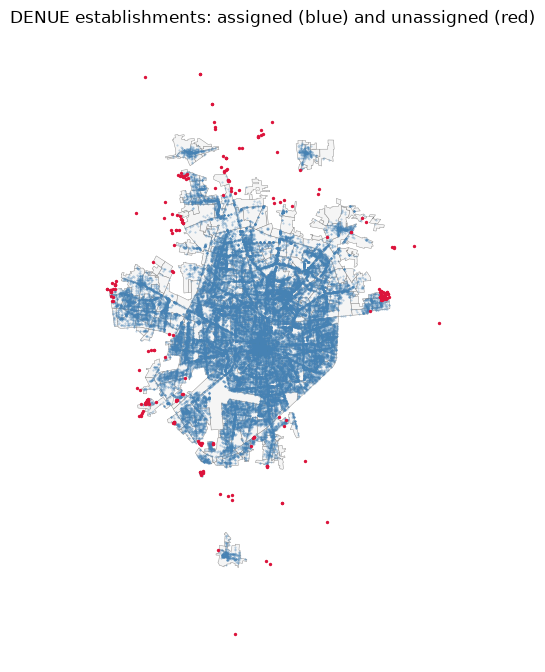

In [16]:
fig, ax = plt.subplots(figsize=(8, 8))
ageb.plot(ax=ax, facecolor="whitesmoke", edgecolor="grey", linewidth=0.3)
joined[matched].plot(ax=ax, markersize=0.2, color="steelblue", alpha=0.4)
joined[~matched].plot(ax=ax, markersize=2, color="crimson")
ax.set_title("DENUE establishments: assigned (blue) and unassigned (red)")
ax.set_axis_off()
plt.show()

**Reading.** Most unassigned points are establishments whose declared AGEB is not an urban
AGEB (rural localities and the rural remainder of the municipality): they are outside the study
area. The rest declare an urban AGEB but their coordinates fall just outside every polygon.
Both groups are counted and reported, not silently dropped. Among assigned points, the spatial
result agrees with the key declared by INEGI in almost every case, which validates the join.

## 7. Public-safety source

The georeferenced incident dataset is being confirmed with the instructor. The same test applies
once it is available: latitude/longitude to WGS84 points, `within` join to the AGEB polygons,
and a report of matched and unmatched incidents. The pipeline reads incidents through a single
extract step with a fixed output (id, latitude, longitude, crime type, date, hour), so the source
can be replaced without touching the rest of the code.

In [17]:
out = config.OUTPUTS / "phase1_assessment.json"
out.write_text(json.dumps(summary, indent=2, ensure_ascii=False, default=str) + "\n", encoding="utf-8")
print("saved", out.relative_to(config.ROOT))

saved outputs\phase1_assessment.json
